# Лабораторная №2, курс ASR

## Импорты и константы

In [1]:
%matplotlib inline

from IPython.display import Image, display
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf

In [2]:
LAB_DIR = Path.cwd()
if not (LAB_DIR / "data/manifest.jsonl").exists():
    LAB_DIR = LAB_DIR / "lab_02_ru"

DATA_DIR = LAB_DIR / "data"
OUTPUTS_DIR = LAB_DIR / "outputs"
AUGMENTED_DIR = OUTPUTS_DIR / "augmented"
RESULTS_DIR = OUTPUTS_DIR / "results"
FIGURES_DIR = OUTPUTS_DIR / "figures"

ITEM_ID = "1272-128104-0000"
SR = 16_000

In [3]:
manifest = pd.read_json(DATA_DIR / "manifest.jsonl", lines=True)
per_item = pd.read_csv(RESULTS_DIR / "per_item_results.csv")
aggregate = pd.read_csv(RESULTS_DIR / "aggregate_results.csv")

print(f"Примеров: {len(manifest)}")
print(f"Результатов распознавания: {len(per_item)}")
display(manifest[["item_id", "duration_seconds", "reference_normalized"]])

Примеров: 5
Результатов распознавания: 35


,item_id,duration_seconds,reference_normalized
0,1272-128104-0000,5.855,mister quilter is the apostle of the middle cl...
1,1272-128104-0001,4.815,nor is mister quilter's manner less interestin...
2,1272-128104-0003,9.900,he has grave doubts whether sir frederick leig...
3,1272-128104-0006,5.640,on the general principles of art mister quilte...
4,1272-128104-0007,9.240,painting he tells us is of a different quality...


## Задание 1. Как аугментации меняют сигнал

Для сравнения возьму сильный шум `noise_0db` и реверберацию `reverb_room_a`. Посмотрим на волновую форму и log-Mel одного и того же примера.

In [4]:
def log_mel(audio, sample_rate=SR):
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sample_rate, n_fft=400, hop_length=160,
        win_length=400, n_mels=80, fmin=20, fmax=7600
    )
    return librosa.power_to_db(mel, ref=np.max)


def load_condition(item_id, condition):
    path = AUGMENTED_DIR / f"{item_id}__{condition}.wav"
    audio, sample_rate = librosa.load(path, sr=SR, mono=True)
    return audio, sample_rate


def plot_conditions(item_id, conditions):
    fig, axes = plt.subplots(len(conditions), 2, figsize=(13, 3.2 * len(conditions)))
    for row, condition in enumerate(conditions):
        audio, sample_rate = load_condition(item_id, condition)
        librosa.display.waveshow(audio, sr=sample_rate, ax=axes[row, 0], color="#315c8a")
        axes[row, 0].set_title(f"{condition}: волновая форма")
        image = librosa.display.specshow(
            log_mel(audio, sample_rate), sr=sample_rate, hop_length=160,
            x_axis="time", y_axis="mel", cmap="viridis", ax=axes[row, 1]
        )
        axes[row, 1].set_title(f"{condition}: log-Mel")
        fig.colorbar(image, ax=axes[row, 1], format="%+2.0f dB")
    fig.tight_layout()
    plt.show()

In [5]:
plot_conditions(ITEM_ID, ["clean", "noise_0db", "reverb_room_a"])

На графиках видно два основных изменения:

1. При `noise_0db` шум есть на всей записи, даже в паузах. На log-Mel появляется яркий фон почти по всему спектру, поэтому речь видна хуже.
2. При `reverb_room_a` после звуков остаются хвосты. Из-за них соседние участки речи немного накладываются друг на друга.

## Задание 2. Реверберация против шума

Для шума беру вариант `noise_0db`. У него на спектре появляется почти равномерный фон. Реверберация выглядит иначе: энергия от звука еще некоторое время тянется после него. Получаются хвосты и размытые границы. Это и есть временное размытие. Шум в основном просто закрывает полезный сигнал.

## Задание 3. Speed perturbation и длительность

In [6]:
duration_rows = []
for condition in ["clean", "speed_0.9x", "speed_1.1x"]:
    path = AUGMENTED_DIR / f"{ITEM_ID}__{condition}.wav"
    info = sf.info(path)
    duration_rows.append([condition, info.frames / info.samplerate])

durations = pd.DataFrame(duration_rows, columns=["Условие", "Длительность, с"])
durations["Относительно clean"] = durations["Длительность, с"] / durations.loc[0, "Длительность, с"]
display(durations.round(3))

,Условие,"Длительность, с",Относительно clean
0,clean,5.855,1.000
1,speed_0.9x,6.506,1.111
2,speed_1.1x,5.323,0.909


При `0.9x` речь замедляется, поэтому запись становится примерно в `1.11` раза длиннее. При `1.1x` речь ускоряется, поэтому длина уменьшается примерно до `0.91` от исходной.

Но только по длительности нельзя угадать WER. Для модели важна не сама длина файла, а то, как после изменения скорости выглядят звуки и переходы между ними. К небольшому изменению темпа модель вообще может быть устойчивой.

## Задание 4. SpecAugment

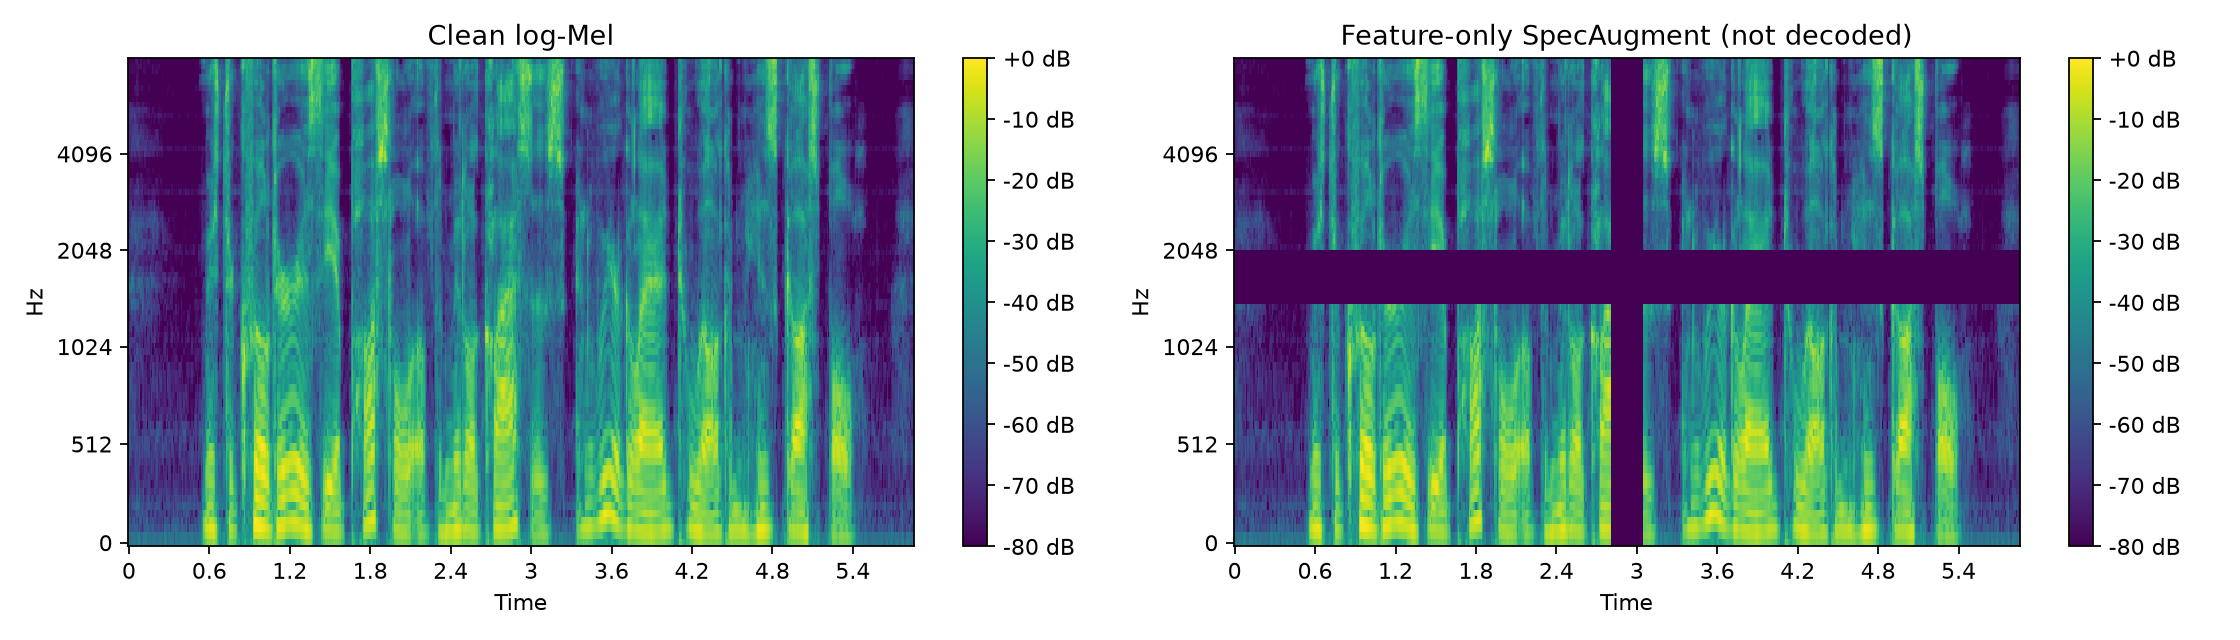

Временная маска: 2.81-3.05 с
Частотная маска: mel-бины 35-44, примерно 1399-1978 Гц


In [7]:
display(Image(filename=FIGURES_DIR / "specaugment_feature_only.png"))

time_start = 281
time_width = 24
mel_frequencies = librosa.mel_frequencies(n_mels=80, fmin=20, fmax=7600)

print(f"Временная маска: {time_start * 160 / SR:.2f}-{(time_start + time_width) * 160 / SR:.2f} с")
print(f"Частотная маска: mel-бины 35-44, примерно {mel_frequencies[35]:.0f}-{mel_frequencies[44]:.0f} Гц")

Вертикальная полоса скрывает небольшой кусок записи примерно от `2.81` до `3.05` секунды сразу на всех частотах. Горизонтальная полоса скрывает частоты примерно от `1.4` до `2.0` кГц на протяжении всей записи.

Это может быть полезно при обучении: модель учится не надеяться только на один кусок времени или один диапазон частот. Ей приходится смотреть на соседние участки. Здесь SpecAugment применяется к признакам, а не к самому WAV, поэтому этот вариант мы не подавали в Whisper.

## Общие результаты ASR

In [8]:
aggregate_sorted = aggregate.sort_values("mean_wer", ascending=False)
display(aggregate_sorted.round(3))

plot_data = aggregate_sorted.set_index("condition")[["mean_wer", "mean_cer"]]
ax = plot_data.plot.bar(figsize=(11, 5), color=["#315c8a", "#d99036"])
ax.set_title("Средние WER и CER по условиям")
ax.set_xlabel("Условие")
ax.set_ylabel("Ошибка")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

,condition,utterance_count,reference_word_count,mean_wer,mean_cer,mean_rtf
1,noise_0db,5,82,0.782,0.432,0.124
2,noise_10db,5,82,0.149,0.085,0.061
3,noise_20db,5,82,0.129,0.072,0.059
4,reverb_room_a,5,82,0.121,0.061,0.061
6,speed_1.1x,5,82,0.087,0.054,0.068
0,clean,5,82,0.084,0.050,0.084
5,speed_0.9x,5,82,0.084,0.048,0.057


## Задание 5. Один пример в трех условиях

Беру пример `1272-128104-0001` и сравниваю чистый сигнал с шумом 10 дБ и 0 дБ.

In [9]:
example_id = "1272-128104-0001"
example_conditions = ["clean", "noise_10db", "noise_0db"]
example = per_item.query(
    "item_id == @example_id and condition in @example_conditions"
).set_index("condition").loc[example_conditions].reset_index()

display(example[["condition", "wer", "cer", "rtf", "hypothesis_normalized"]].round(3))
print("Эталон:")
print(example.iloc[0]["reference_normalized"])

,condition,wer,cer,rtf,hypothesis_normalized
0,clean,0.1,0.063,0.092,nor is mr quilter's manner less interesting th...
1,noise_10db,0.3,0.143,0.083,nor is mr colter's matter less interesting tha...
2,noise_0db,1.2,0.524,0.460,norers mr courters and many of us in question ...


Эталон:
nor is mister quilter's manner less interesting than his matter


Сильнее всего изменился WER: `0.10 -> 0.30 -> 1.20`. CER тоже вырос, но слабее: `0.063 -> 0.143 -> 0.524`. При шуме 0 дБ речь и шум имеют примерно одинаковую мощность. Из-за этого модель начинает путать и пропускать целые слова.

RTF на самом сложном варианте тоже вырос. Но RTF показывает скорость работы, а не качество распознавания. Он зависит еще и от компьютера и текущей нагрузки.

## Задание 6. Худший результат ASR

In [10]:
worst = aggregate.loc[aggregate["mean_wer"].idxmax()]
print(f"Условие: {worst['condition']}")
print(f"mean WER: {worst['mean_wer']:.3f}")
print(f"mean CER: {worst['mean_cer']:.3f}")
print(f"mean RTF: {worst['mean_rtf']:.3f}")

worst_example = per_item.query(
    "item_id == @example_id and condition == @worst.condition"
).iloc[0]
print("\nЭталон:")
print(worst_example["reference_normalized"])
print("\nГипотеза:")
print(worst_example["hypothesis_normalized"])

Условие: noise_0db
mean WER: 0.782
mean CER: 0.432
mean RTF: 0.124

Эталон:
nor is mister quilter's manner less interesting than his matter

Гипотеза:
norers mr courters and many of us in question then who's madder


Самый плохой результат получился у `noise_0db`: `mean_wer = 0.782`, `mean_cer = 0.432`. При SNR 0 дБ мощность шума примерно равна мощности речи. Из-за этого хуже слышны согласные и границы слов. Модель начинает заменять даже целые куски фразы.

## Задание 7. Когда WER и CER выглядят по-разному

Возьмем `noise_10db` для записи `1272-128104-0001`. Здесь WER равен `0.30`, а CER только `0.143`.

Эталон: `nor is mister quilter's manner less interesting than his matter`

Гипотеза: `nor is mr colter's matter less interesting than his matter`

WER считает слово неправильным целиком. Поэтому замены `mister -> mr`, `quilter's -> colter's` и `manner -> matter` дают три ошибки. Но сами слова похожи по буквам, поэтому CER вырос не так сильно.

## Задание 8. Одинаковая ошибка при разных аугментациях

Для `1272-128104-0000` чистый сигнал, шум 20 дБ, шум 10 дБ, реверберация и оба изменения скорости дали одну и ту же гипотезу:

Эталон: `mister quilter is the apostle of the middle classes and we are glad to welcome his gospel`

Гипотеза: `mr quilter is the apostle of the middle classes and we are glad to welcome his gospel`

Скорее всего, это предпочтение декодера или языковой части модели. Сокращение `mr` выглядит естественно и появляется даже на чистом сигнале. Если бы причина была только в шуме или реверберации, одна и та же ошибка в таком количестве разных вариантов была бы менее ожидаемой.

## Задание 9. Можно ли обобщать результат

Тут важно разделять аугментацию при обучении и искажение тестового сигнала. Мы не обучали модель на измененных записях. Мы взяли уже готовую `tiny.en` и подали ей чистые и искаженные аудио. Поэтому в этой работе мы проверяем устойчивость модели к шуму, реверберации и изменению скорости.

Высокий WER у `noise_0db` означает только то, что `tiny.en` плохо распознала наши записи с шумом 0 дБ. Это не означает, что шумовая аугментация вредна при обучении. Наоборот, обучение с шумом могло бы сделать модель устойчивее.

Чтобы проверить пользу аугментации, надо было бы обучить две одинаковые модели: одну на обычных данных, а вторую на данных с аугментацией. После этого обе модели нужно проверить на отдельном чистом и зашумленном тестовом наборе.

Еще у нас всего 5 записей и одна модель `tiny.en`. Поэтому результат показывает поведение только этой модели в нашем небольшом тесте.

## Вывод

Небольшое изменение скорости почти не повлияло на результат. Реверберация и слабый шум немного ухудшили качество. Хуже всего модель сработала с шумом 0 дБ. При этом некоторые ошибки повторялись даже на чистом сигнале. Значит, часть ошибок связана не с искажением аудио, а с самой моделью и декодером. В этой работе мы проверили устойчивость готовой модели, но не проверяли пользу аугментации при обучении.